In [1]:
from mlwpy import *
%matplotlib inline

In [2]:
iris = datasets.load_iris()

tts = skms.train_test_split(iris.data,iris.target,test_size = .33, random_state = 21)

(iris_train_ftrs,iris_test_ftrs,iris_train_tgt,iris_test_tgt) = tts

#### Baseline Classifiers

In [3]:
baseline = dummy.DummyClassifier(strategy = "most_frequent")
baseline.fit(iris_train_ftrs,iris_train_tgt)
baseline_preds = baseline.predict(iris_test_ftrs)
baseline_acc = metrics.accuracy_score(baseline_preds, iris_test_tgt)
print(baseline_acc)

0.3


In [4]:
strategies = ['constant','uniform','stratified','prior','most_frequent']

#set up args to create different DummyClassifier strategies
baseline_args = [{'strategy':s} for s in strategies]
baseline_args[0]['constant'] = 0 #class 0 is setosa

accuracies = []
for bla in baseline_args:
    baseline = dummy.DummyClassifier(**bla)
    baseline.fit(iris_train_ftrs,iris_train_tgt)
    baseline_preds = baseline.predict(iris_test_ftrs)
    accuracies.append(metrics.accuracy_score(baseline_preds,iris_test_tgt))

df = pd.DataFrame({'accuracy':accuracies}, index = strategies)
df

,accuracy
constant,0.3600
uniform,0.3800
stratified,0.3400
prior,0.3000
most_frequent,0.3000


#### Metrics for Classification

In [5]:

# helpful stdlib tool for cleaning up printouts
import textwrap
print(textwrap.fill(str(sorted(metrics.get_scorer_names())), 
                    width=70))

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score',
'average_precision', 'balanced_accuracy', 'completeness_score',
'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples',
'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score',
'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples',
'jaccard_weighted', 'matthews_corrcoef', 'max_error',
'mutual_info_score', 'neg_brier_score', 'neg_log_loss',
'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error',
'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance',
'neg_mean_squared_error', 'neg_mean_squared_log_error',
'neg_median_absolute_error', 'neg_negative_likelihood_ratio',
'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error',
'normalized_mutual_info_score', 'positive_likelihood_ratio',
'precision', 'precision_macro', 'precision_micro',
'precision_samples', 'precision_weighted', 'r2', 'rand_score',
'recall', 'recall_macro', 'recall_micro', 'recall_samples',
'recall_weighted', 'roc_auc',

In [6]:
knn = neighbors.KNeighborsClassifier()

# help(knn.score) # verbose, but complete

print(knn.score.__doc__.splitlines()[0])
print('\n---and---\n')
print("\n".join(knn.score.__doc__.splitlines()[-6:]))



---and---


        Returns
        -------
        score : float
            Mean accuracy of ``self.predict(X)`` w.r.t. `y`.
        


#### Confusion Matrix

In [7]:
tgt_preds = (neighbors.KNeighborsClassifier()
                      .fit(iris_train_ftrs, iris_train_tgt)
                      .predict(iris_test_ftrs))

accuracy  = metrics.accuracy_score(tgt_preds, iris_test_tgt)
print("accuracy",accuracy)
cm = metrics.confusion_matrix(tgt_preds, iris_test_tgt)
print("confusion matrix:", cm, sep="\n")


accuracy 0.94
confusion matrix:
[[18  0  0]
 [ 0 16  2]
 [ 0  1 13]]


Text(20.72222222222222, 0.5, 'Actual')

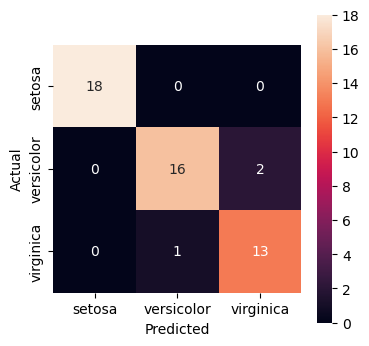

In [8]:
ax,fig = plt.subplots(1,1,figsize=(4,4))
ax = sns.heatmap(cm, annot= True, square = True,
                xticklabels = iris.target_names,
                yticklabels = iris.target_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

In [9]:
macro_prec = metrics.precision_score(iris_test_tgt,tgt_preds, average = 'macro')

print("macro:",macro_prec)

cm = metrics.confusion_matrix(iris_test_tgt,tgt_preds)
n_labels = len(iris.target_names)
print(
    "should be equal macroaverage:",
    (np.diag(cm)/cm.sum(axis=0)).sum() / n_labels
)

macro: 0.9391534391534391
should be equal macroaverage: 0.9391534391534391


In [10]:
micro_prec = metrics.precision_score(iris_test_tgt,tgt_preds, average = 'micro')

print('micro:',micro_prec)

cm = metrics.confusion_matrix(iris_test_tgt, tgt_preds)
print("should be equal microaverage:",
     (np.diag(cm).sum())/cm.sum())

micro: 0.94
should be equal microaverage: 0.94


In [11]:
print(metrics.classification_report(iris_test_tgt, tgt_preds))

#verify sum-across rows
cm = metrics.confusion_matrix(iris_test_tgt, tgt_preds)
print("row counts equal support:",cm.sum(axis=1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.89      0.94      0.91        17
           2       0.93      0.87      0.90        15

    accuracy                           0.94        50
   macro avg       0.94      0.94      0.94        50
weighted avg       0.94      0.94      0.94        50

row counts equal support: [18 17 15]
